In [35]:
!pip install pandas numpy matplotlib seaborn scikit-learn xlrd

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [37]:
#loading dataset

df = pd.read_excel(r"C:\Users\saksh\OneDrive\Concrete_Data.xls")
print("First 5 records")
print(df.head())

#no of rows n columns:
print("\nShape of Dataset:")
print(df.shape)
#datatypes for each values:
print("\nData Types:")
print(df.dtypes)
cement = df.iloc[:, 0]
blast_furnace_slag = df.iloc[:, 1]
fly_ash = df.iloc[:, 2]
water = df.iloc[:, 3]
superplasticizer = df.iloc[:, 4]
coarse_aggregate = df.iloc[:, 5]
fine_aggregate = df.iloc[:, 6]
age = df.iloc[:, 7]
concrete_compressive_strength = df.iloc[:, 8]
#missing values:
print("\nMissing Values:")
print(df.isnull().sum())
#duplicate records:
print("\nDuplicate Records")
print(df.duplicated().sum())
#report my findings:
print("\nReport Findings")

print("The dataset contains", df.shape[0], "rows and", df.shape[1], "columns.")
print("All variables are numerical.")

if df.isnull().sum().sum() == 0:
    print("No missing values are present.")
else:
    print("Missing values are present in the dataset.")

print("Number of duplicate records:", df.duplicated().sum())



First 5 records
   Cement (component 1)(kg in a m^3 mixture)  \
0                                      540.0   
1                                      540.0   
2                                      332.5   
3                                      332.5   
4                                      198.6   

   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
0                                                0.0       
1                                                0.0       
2                                              142.5       
3                                              142.5       
4                                              132.4       

   Fly Ash (component 3)(kg in a m^3 mixture)  \
0                                         0.0   
1                                         0.0   
2                                         0.0   
3                                         0.0   
4                                         0.0   

   Water  (component 4)(kg in a m^3 mix

In [38]:
#separation of dataset into X n y
# Features and Target

X = df.iloc[:, :-1]
y = df.iloc[:, -1]
#spliting the dataset 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Features Shape: (1030, 8)
Target Shape: (1030,)
Training Data Shape: (824, 8)
Testing Data Shape: (206, 8)


In [39]:
#Linear reg:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
#r2score n RMSE

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("\nLinear Regression Results")
print("R2 Score:", r2_lr)
print("RMSE:", rmse_lr)


Linear Regression Results
R2 Score: 0.6275416055429018
RMSE: 9.796707832398448


In [40]:
#ridge reg:
#alpa value used
alpha_ridge = 1.0

ridge = Ridge(alpha=alpha_ridge)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
#r2score n RMSE

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("\nRidge Regression Results")
print("Alpha:", alpha_ridge)
print("R2 Score:", r2_ridge)
print("RMSE:", rmse_ridge)


Ridge Regression Results
Alpha: 1.0
R2 Score: 0.6275417727142356
RMSE: 9.796705633859064


In [20]:
#lasso reg:
#alpha value used:
alpha_lasso = 0.1

lasso = Lasso(alpha=alpha_lasso)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)
#r2score n RMSE:

r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("\nLasso Regression Results")
print("Alpha:", alpha_lasso)
print("R2 Score:", r2_lasso)
print("RMSE:", rmse_lasso)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})
#zero coeff:

zero_features = coef_df[coef_df['Coefficient'] == 0]

print("\nFeatures with Zero Coefficients:")
print(zero_features)
print("\nInterpretation:")

if len(zero_features) == 0:
    print("No feature has a zero coefficient. All features contribute to the prediction.")
else:
    print("Features with zero coefficients are considered less important by the Lasso model and are effectively removed from prediction.")


Lasso Regression Results
Alpha: 0.1
R2 Score: 0.6275630625810791
RMSE: 9.796425637977983

Features with Zero Coefficients:
Empty DataFrame
Columns: [Feature, Coefficient]
Index: []

Interpretation:
No feature has a zero coefficient. All features contribute to the prediction.


In [21]:
#random rainforest reg:
#no of estimators used
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
# r2score n RMSE:
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\nRandom Forest Results")
print("Number of Estimators:", 100)
print("R2 Score:", r2_rf)
print("RMSE:", rmse_rf)
#comparison:
print("\nComparison of Models")

comparison = pd.DataFrame({
    'Model': ['Linear Regression',
              'Ridge Regression',
              'Lasso Regression',
              'Random Forest'],
    'R2 Score': [r2_lr, r2_ridge, r2_lasso, r2_rf],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso, rmse_rf]
})

print(comparison)
best_model = comparison.loc[comparison['R2 Score'].idxmax(), 'Model']

print("\nInterpretation:")
print("Random Forest results are compared with Linear Regression, Ridge Regression, and Lasso Regression.")
print("The model with the highest R² Score and lowest RMSE is generally considered the best performer.")
print("Best Performing Model:", best_model)


Random Forest Results
Number of Estimators: 100
R2 Score: 0.8821874643599863
RMSE: 5.509815094430036

Comparison of Models
               Model  R2 Score      RMSE
0  Linear Regression  0.627542  9.796708
1   Ridge Regression  0.627542  9.796706
2   Lasso Regression  0.627563  9.796426
3      Random Forest  0.882187  5.509815

Interpretation:
Random Forest results are compared with Linear Regression, Ridge Regression, and Lasso Regression.
The model with the highest R² Score and lowest RMSE is generally considered the best performer.
Best Performing Model: Random Forest


In [22]:
# FI:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(feature_importance)


Feature Importance
                                             Feature  Importance
7                                          Age (day)    0.333626
0          Cement (component 1)(kg in a m^3 mixture)    0.323130
3          Water  (component 4)(kg in a m^3 mixture)    0.125596
1  Blast Furnace Slag (component 2)(kg in a m^3 m...    0.076872
4  Superplasticizer (component 5)(kg in a m^3 mix...    0.058080
6  Fine Aggregate (component 7)(kg in a m^3 mixture)    0.035362
5  Coarse Aggregate  (component 6)(kg in a m^3 mi...    0.028352
2         Fly Ash (component 3)(kg in a m^3 mixture)    0.018982


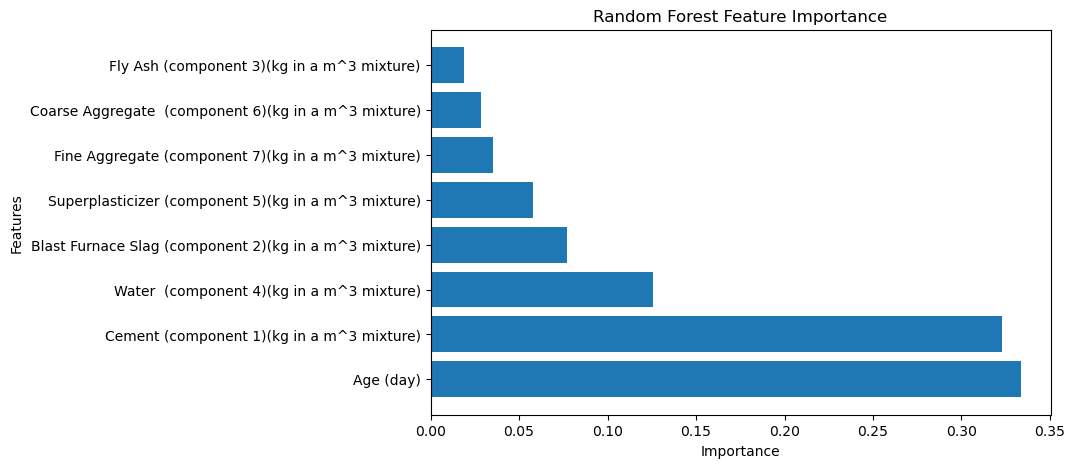

In [23]:
#plot FI:
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.show()

In [24]:
#top 3 features:
top3 = feature_importance.head(3)

print("\nTop 3 Most Influential Features")
print(top3)


Top 3 Most Influential Features
                                     Feature  Importance
7                                  Age (day)    0.333626
0  Cement (component 1)(kg in a m^3 mixture)    0.323130
3  Water  (component 4)(kg in a m^3 mixture)    0.125596


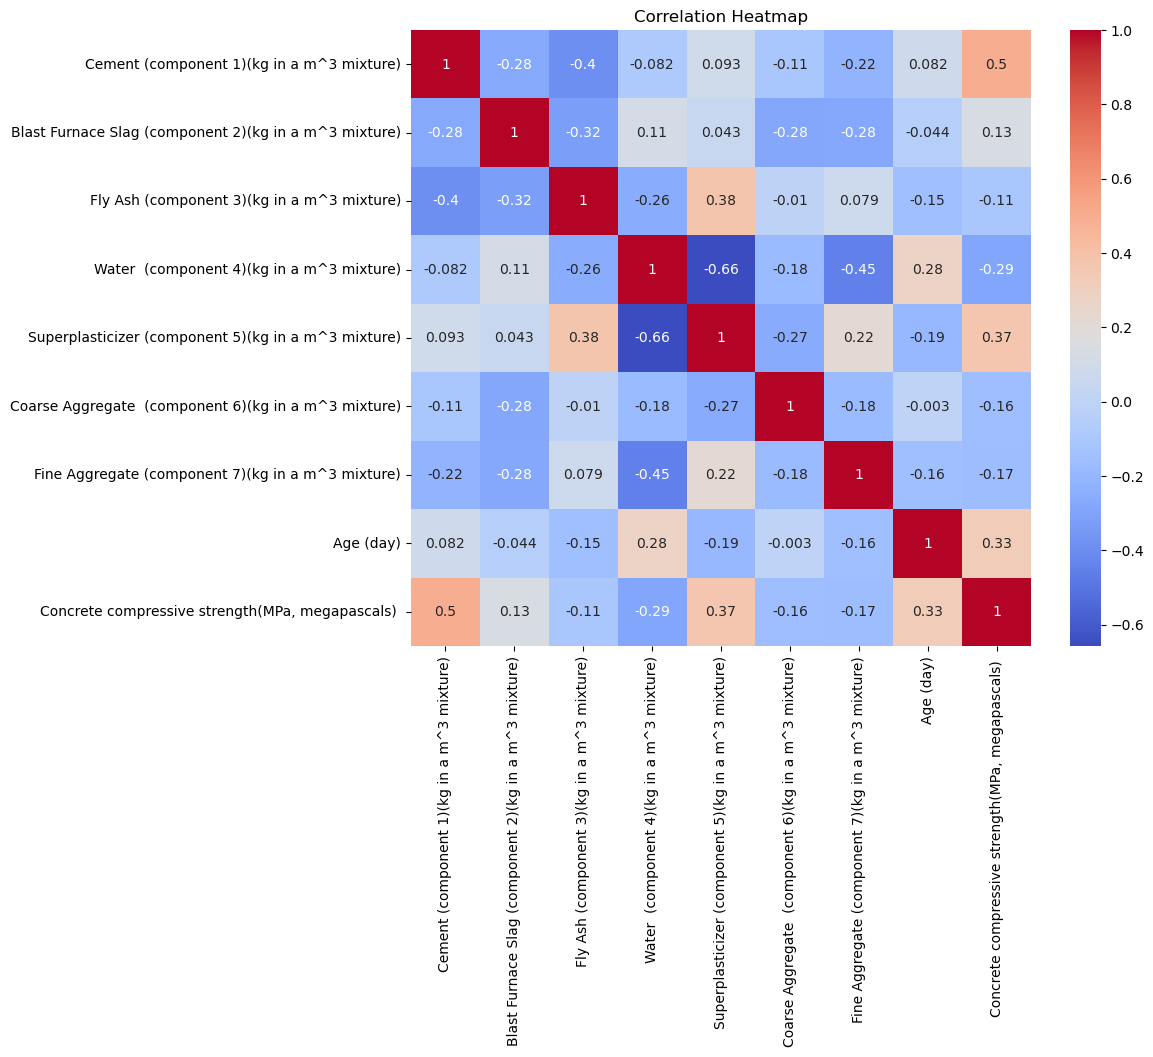


Highest Positive Correlation with Strength:
Cement (component 1)(kg in a m^3 mixture)

Weakest Correlation with Strength:
Fly Ash (component 3)(kg in a m^3 mixture)


In [25]:
#correlation heatmap: 
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()
#highest n weakest correlation w compressive strength:
corr_strength = df.corr().iloc[:-1, -1]

highest = corr_strength.idxmax()
weakest = corr_strength.abs().idxmin()

print("\nHighest Positive Correlation with Strength:")
print(highest)

print("\nWeakest Correlation with Strength:")
print(weakest)

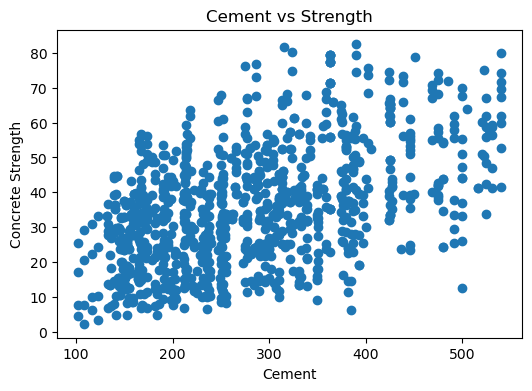

In [26]:
#scatter plots:
#1) cement vs strength
plt.figure(figsize=(6,4))

plt.scatter(
    df.iloc[:,0],
    df.iloc[:,-1]
)

plt.xlabel("Cement")
plt.ylabel("Concrete Strength")
plt.title("Cement vs Strength")

plt.show()

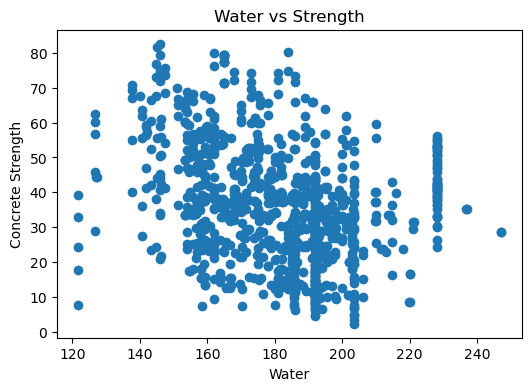

In [28]:
#2) water vs strength:
plt.figure(figsize=(6,4))

plt.scatter(
    df.iloc[:,3],
    df.iloc[:,-1]
)

plt.xlabel("Water")
plt.ylabel("Concrete Strength")
plt.title("Water vs Strength")

plt.show()

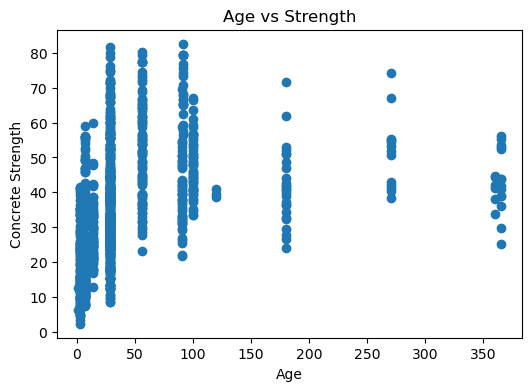

In [29]:
#age vs strength:
plt.figure(figsize=(6,4))

plt.scatter(
    df.iloc[:,7],
    df.iloc[:,-1]
)

plt.xlabel("Age")
plt.ylabel("Concrete Strength")
plt.title("Age vs Strength")

plt.show()

In [33]:
print("\n1) Which varible shows the strongest relationship with strength?")

print("Variable with the strongest relationship:",
      highest)


1) Which varible shows the strongest relationship with strength?
Variable with the strongest relationship: Cement (component 1)(kg in a m^3 mixture)


In [34]:
print("\n Is the relationship linear or non-linear?")

print("The relationship appears approximately linear for some variables such as Cement.")
print("Age often shows a non-linear trend where strength increases rapidly and then levels off.")
print("Therefore, the dataset contains both linear and non-linear relationships.")


 Is the relationship linear or non-linear?
The relationship appears approximately linear for some variables such as Cement.
Age often shows a non-linear trend where strength increases rapidly and then levels off.
Therefore, the dataset contains both linear and non-linear relationships.
